In [25]:
from google.colab import files
uploaded = files.upload()

Saving credit_card.csv to credit_card.csv


In [26]:
import pandas as pd

df = pd.read_csv("credit_card.csv")

In [28]:
print(df.columns)

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



📊 MANUAL METRICS
Accuracy: 0.8953603158933859
Precision: 0.7839195979860105
Recall: 0.4799999999985231
F1 Score: 0.5954198468548817

📊 SKLEARN REPORT
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1701
           1       0.78      0.48      0.60       325

    accuracy                           0.90      2026
   macro avg       0.85      0.73      0.77      2026
weighted avg       0.89      0.90      0.88      2026



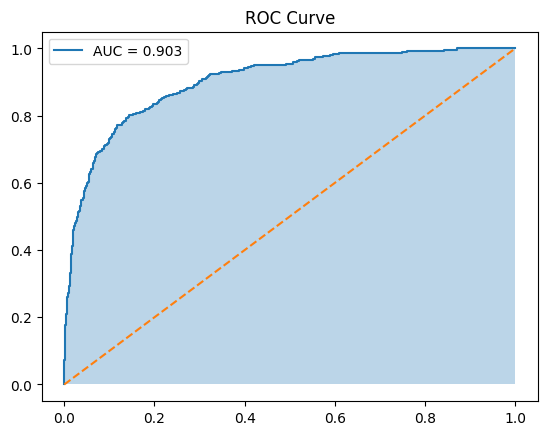

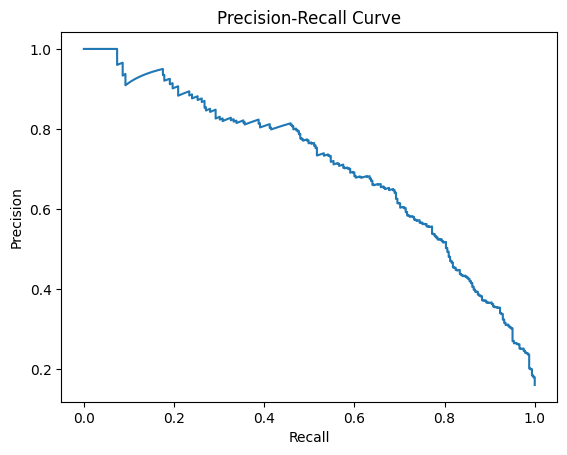

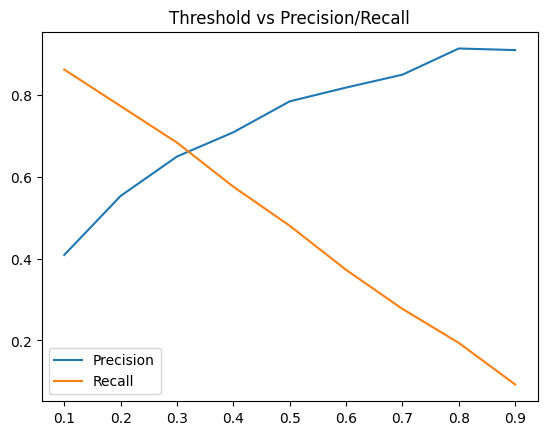


📊 FINAL SUMMARY
      Metric     Value
0   Accuracy  0.895360
1  Precision  0.783920
2     Recall  0.480000
3         F1  0.595420
4        AUC  0.903176


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

# ================================
# 1. LOAD DATA
# ================================
df = pd.read_csv("credit_card.csv")

# ================================
# 2. TARGET FIX
# ================================
target_column = "Attrition_Flag"

df[target_column] = df[target_column].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

# ================================
# 3. DROP UNNEEDED COLUMNS
# ================================
df = df.drop(columns=[
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
])

# ================================
# 4. ENCODE CATEGORICAL DATA
# ================================
df = pd.get_dummies(df, drop_first=True)

# ================================
# 5. SPLIT DATA
# ================================
X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 6. TRAIN MODEL
# ================================
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# ================================
# 7. CONFUSION MATRIX + METRICS
# ================================
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-9)
recall = TP / (TP + FN + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

print("\n📊 MANUAL METRICS")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ================================
# 8. CLASSIFICATION REPORT
# ================================
print("\n📊 SKLEARN REPORT")
print(classification_report(y_test, y_pred))

# ================================
# 9. ROC CURVE
# ================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.fill_between(fpr, tpr, alpha=0.3)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

# ================================
# 10. PRECISION-RECALL CURVE
# ================================
prec, rec, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# ================================
# 11. THRESHOLD ANALYSIS
# ================================
thresholds = np.arange(0.1, 1.0, 0.1)

p_list = []
r_list = []

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    TN, FP, FN, TP = cm_t.ravel()

    p_list.append(TP / (TP + FP + 1e-9))
    r_list.append(TP / (TP + FN + 1e-9))

plt.figure()
plt.plot(thresholds, p_list, label="Precision")
plt.plot(thresholds, r_list, label="Recall")
plt.title("Threshold vs Precision/Recall")
plt.legend()
plt.show()

# ================================
# 12. FINAL SUMMARY
# ================================
summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})

print("\n📊 FINAL SUMMARY")
print(summary)

In [30]:
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved as logistic_model.pkl")

✅ Model saved as logistic_model.pkl


In [31]:
from google.colab import files

files.download("logistic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>